In [17]:
import cv2
import matplotlib.pyplot as plt
# LIBRERIAS
import matplotlib
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = 26, 12 # para modificar el tamaño de la figura
#matplotlib.rc('xtick', labelsize=20)
#matplotlib.rc('ytick', labelsize=20)
font = {'weight' : 'bold',
        'size'   : 24}

matplotlib.rc('font', **font)

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


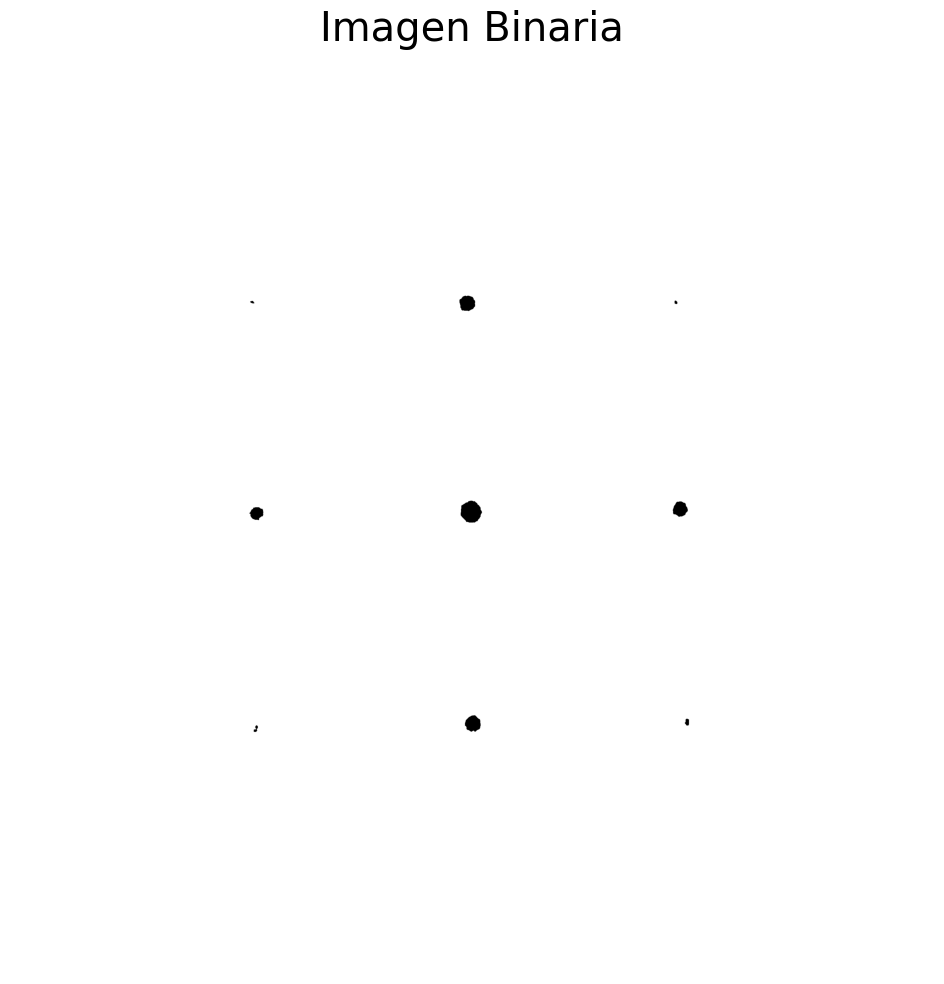

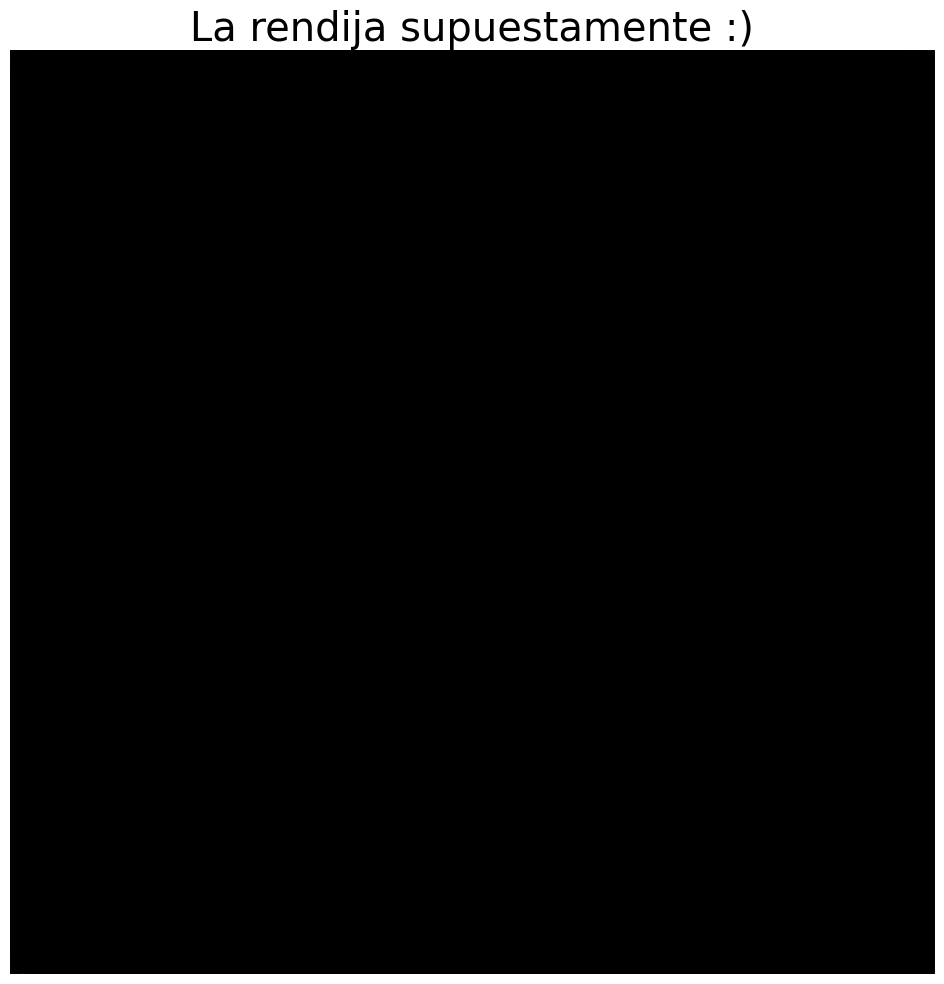

In [27]:
# def procesar_imagen_y_mostrar(filename, tamaño_cuadrado=3023):
#     """
#     Lee una imagen, la convierte en escala de grises, invierte los colores,
#     aplica un umbral binario, la redimensiona a un tamaño cuadrado fijo y muestra la imagen resultante.

#     Args:
#         filename (str): El nombre del archivo de la imagen a procesar.
#         tamaño_cuadrado (int): El tamaño al que se redimensionará la imagen para que sea cuadrada.

#     Returns:
#         numpy.ndarray: La imagen procesada en formato binario.
#     """
#     def imread_to_grayscale(filename):
#         return cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

#     image = imread_to_grayscale(filename)
#     image_invertida = 255 - image

#     # Redimensionar la imagen a un tamaño cuadrado fijo
#     image_cuadrada = cv2.resize(image_invertida, (tamaño_cuadrado, tamaño_cuadrado))

#     # Aplicando umbral binario
#     _, image_binaria = cv2.threshold(image_cuadrada, 200, 255, cv2.THRESH_BINARY)

#     # Mostrando la imagen con Matplotlib
#     plt.imshow(image_binaria, cmap='gray')
#     plt.title('Imagen Binaria')
#     plt.axis('off')  # Ocultar los ejes
#     plt.show()

#     return image_binaria

# # Llamada a la función con el nombre del archivo
# filename = '/content/drive/MyDrive/Física Experimental III/Prelaboratorio 1/Imagenes/Difracción-rejilla-fresnel.jpg'
# imagen_procesada = procesar_imagen_y_mostrar(filename)

# # Parámetros
# L = 0.5
# N = 3023
# dx = 4.8e-4
# lam = 6.33e-7
# k = 2 * np.pi / lam
# z = 0.13

# # Definir variables
# fx = np.linspace(-1 / (2 * dx), 1 / (2 * dx), N)
# FX, FY = np.meshgrid(fx, fx)
# H = np.exp(-1j * np.pi * lam * z * (FX**2 + FY**2))

# # Asegurarse de que H tenga la misma forma que imagen_procesada
# H = H[:imagen_procesada.shape[0], :imagen_procesada.shape[1]]

# # Transformada de Fourier
# u1 = np.fft.fftshift(np.fft.fft2(imagen_procesada) / np.fft.fft2(H))

# # Mostrando u1
# plt.imshow(np.abs(u1), cmap='gray')
# plt.title('La rendija supuestamente :)')
# plt.axis('off')
# plt.show()

# Código NUEVO

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def difraccion_procesada(
    filename,
    resolucion,  # Resolución en metros por píxel
    modo='fraunhofer',
    tamaño_cuadrado=3023,
):
    """
    Procesa una imagen y calcula el patrón de difracción utilizando las aproximaciones
    de Fresnel o Fraunhofer según el modo especificado.

    Args:
        filename (str): Ruta del archivo de la imagen.
        modo (str): 'fresnel' o 'fraunhofer'.
        tamaño_cuadrado (int): Tamaño al que se redimensionará la imagen.
        resolucion (float): Resolución en metros por píxel.

    Returns:
        None. Muestra las imágenes procesadas y los patrones calculados.
    """
    def imread_to_grayscale(filename):
        return cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    # Leer y procesar la imagen
    image = imread_to_grayscale(filename)
    if image is None:
        raise ValueError(f"No se pudo leer el archivo: {filename}")

    # Invertir colores, redimensionar y aplicar umbral binario
    image_invertida = 255 - image
    image_cuadrada = cv2.resize(image_invertida, (tamaño_cuadrado, tamaño_cuadrado))
    _, image_binaria = cv2.threshold(image_cuadrada, 220, 255, cv2.THRESH_BINARY)
    image_binaria = image_binaria / 255  # Normalizar a [0, 1]

    # Mostrar imagen binaria
    plt.imshow(image_binaria, cmap='gray')
    plt.title('Imagen Binaria Procesada')
    plt.axis('off')
    plt.show()

    # Parámetros físicos
    N = image_binaria.shape[0]  # Tamaño de la imagen
    L = N * resolucion  # Tamaño físico de la imagen en metros
    dx = resolucion  # Resolución espacial
    lam = 6.33e-7  # Longitud de onda en metros
    k = 2 * np.pi / lam  # Número de onda
    z = 0.12  # Distancia de propagación en metros (solo Fresnel)

    # Espacio de frecuencias
    fx = np.fft.fftfreq(N, d=dx)  # Frecuencias en x
    fy = np.fft.fftfreq(N, d=dx)  # Frecuencias en y
    FX, FY = np.meshgrid(fx, fy)

    # Calcular patrón de difracción
    if modo == 'fresnel':
        # Propagador de Fresnel
        H = np.exp(-1j * np.pi * lam * z * (FX**2 + FY**2))
        U1 = np.fft.fftshift(np.fft.fft2(image_binaria))  # FFT de la imagen
        U2 = U1 * H  # Multiplicación en el dominio de Fourier
        patron = np.abs(np.fft.ifft2(np.fft.ifftshift(U2)))**2  # Transformada inversa
    elif modo == 'fraunhofer':
        # Transformada de Fourier directa (Fraunhofer)
        U1 = np.fft.fftshift(np.fft.fft2(image_binaria))  # FFT de la imagen
        patron = np.abs(U1)**2  # Intensidad del patrón
    else:
        raise ValueError("El modo debe ser 'fresnel' o 'fraunhofer'.")

    # Normalización para visualizar
    patron /= np.max(patron)

    # Mostrar patrón de difracción
    plt.imshow(
        patron,
        cmap='gray',
        extent=(fx.min(), fx.max(), fy.min(), fy.max())
    )
    plt.title(f'Patrón de Difracción ({modo.capitalize()})')
    plt.xlabel('Frecuencia espacial (fx)')
    plt.ylabel('Frecuencia espacial (fy)')
    plt.colorbar(label='Intensidad normalizada')
    plt.axis('on')
    plt.show()


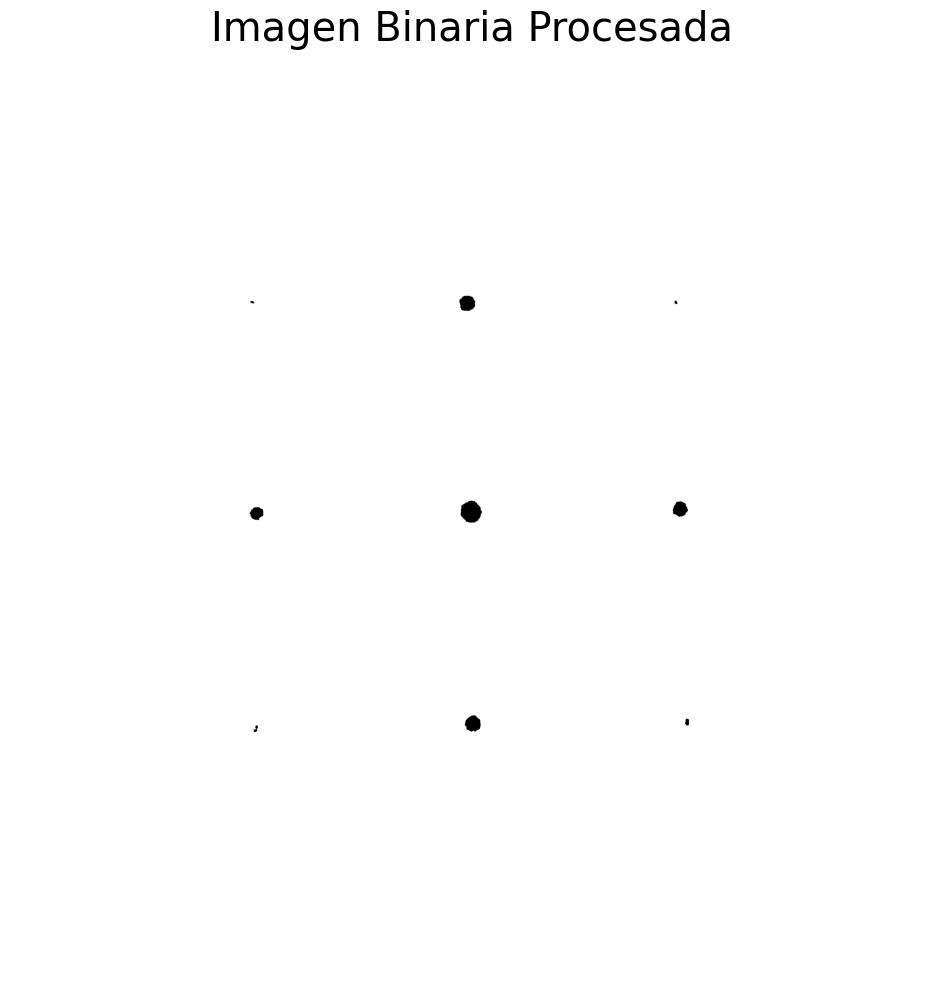

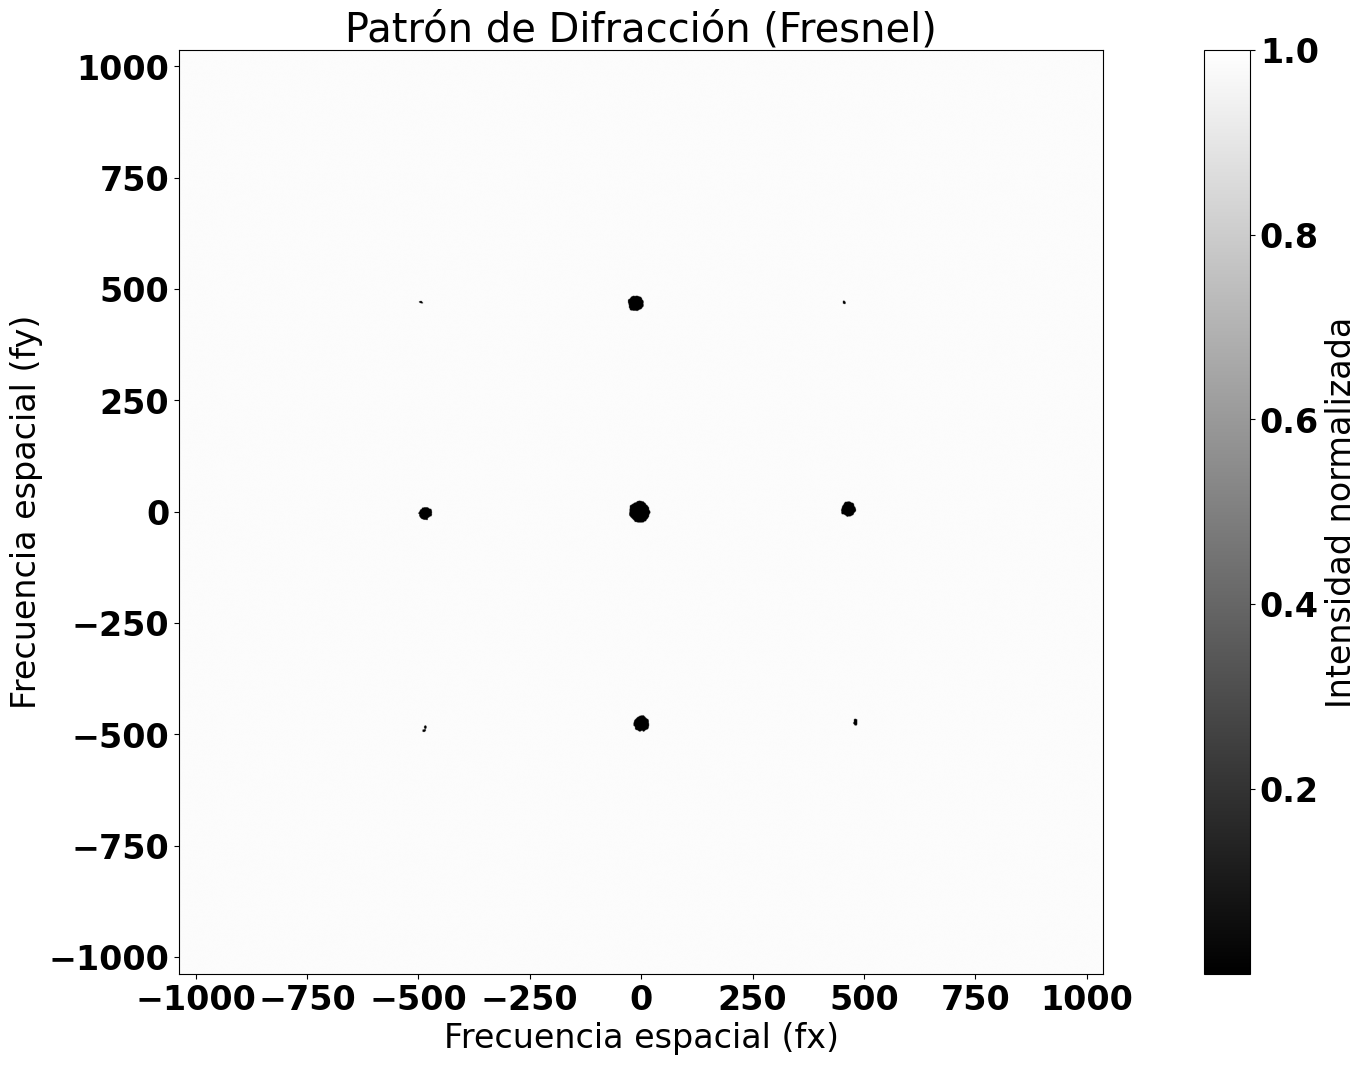

In [22]:
filename = '/content/drive/MyDrive/Física Experimental III/Prelaboratorio 1/Imagenes/Difracción-rejilla-fresnel.jpg'
difraccion_procesada(filename, modo='fresnel', resolucion=0.12 / 249)

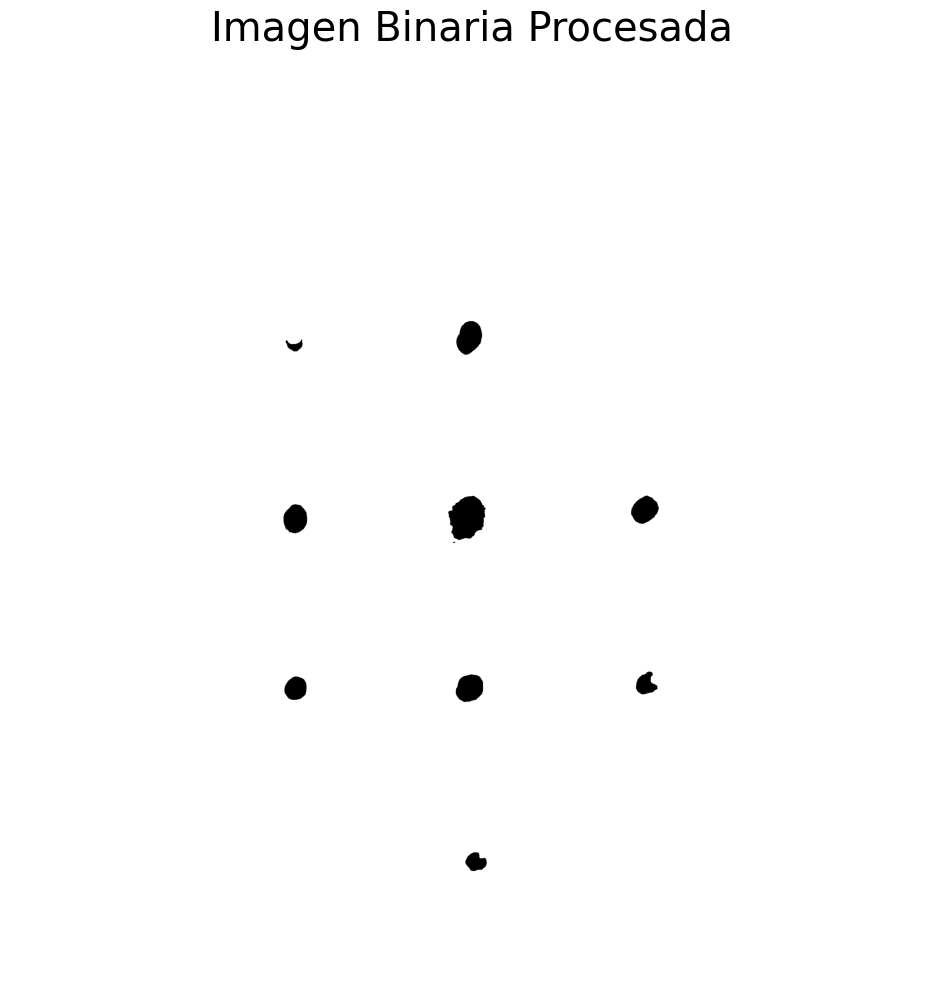

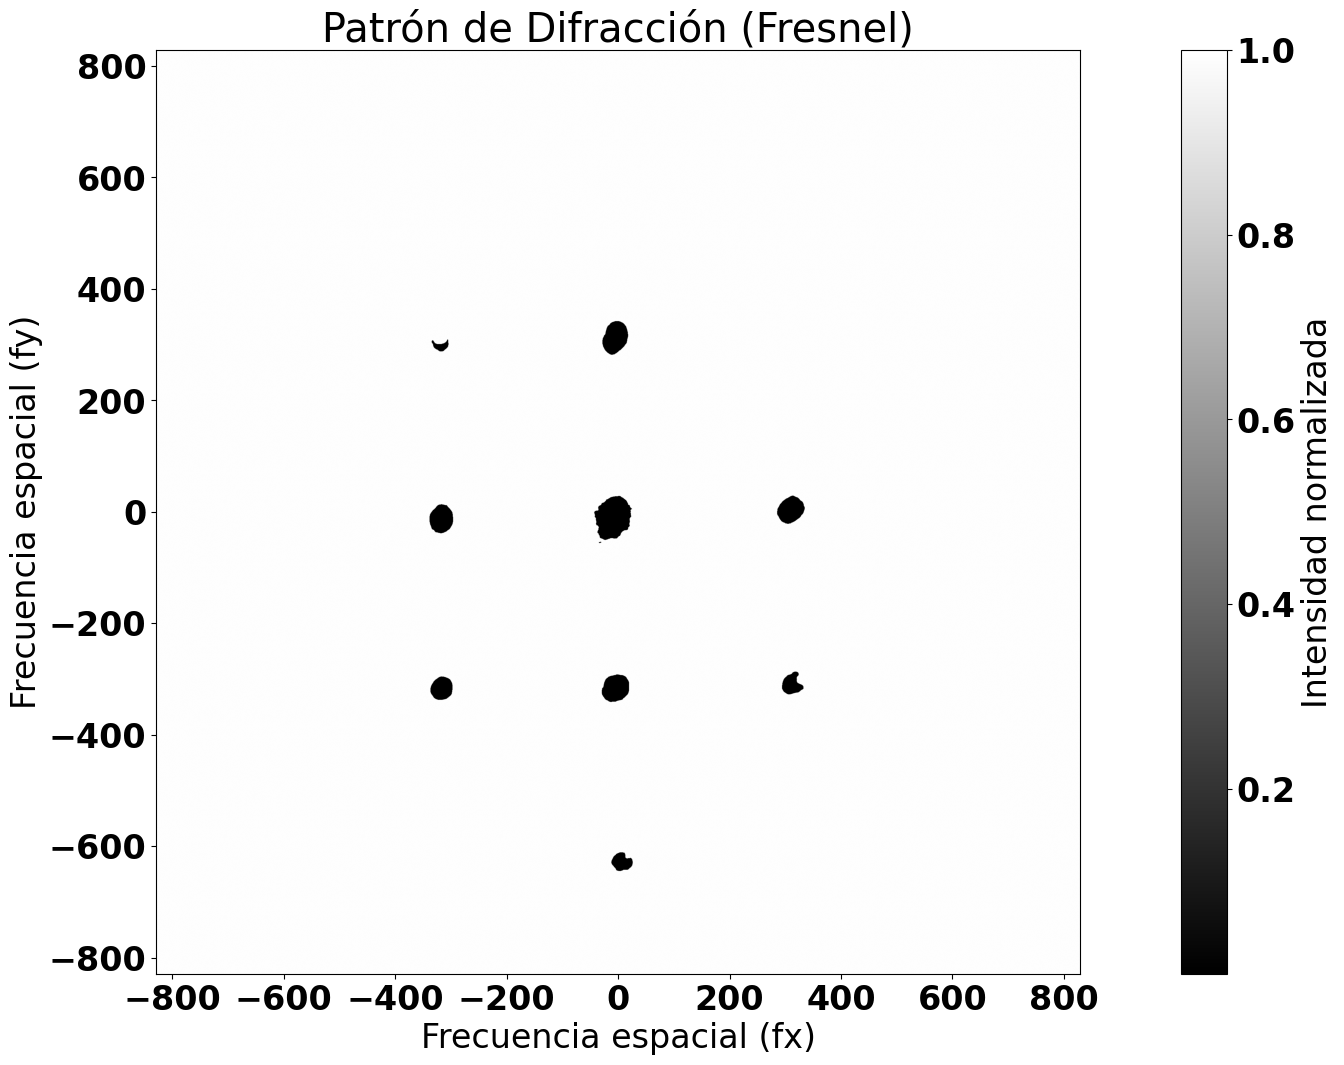

In [33]:
filename = '/content/drive/MyDrive/Física Experimental III/Prelaboratorio 1/Imagenes/Difracción-rejilla-fraunhofer.jpg'
difraccion_procesada(filename, modo='fresnel', resolucion=0.12 / 199)

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def difraccion_procesada(
    filename,
    resolucion,  # Resolución en metros por píxel
    modo='fraunhofer',
    tamaño_cuadrado=3023,
):
    """
    Procesa una imagen y calcula la estructura de la rejilla que generó el patrón
    de difracción utilizando las aproximaciones de Fresnel o Fraunhofer según el modo especificado.

    Args:
        filename (str): Ruta del archivo de la imagen.
        modo (str): 'fresnel' o 'fraunhofer'.
        tamaño_cuadrado (int): Tamaño al que se redimensionará la imagen.
        resolucion (float): Resolución en metros por píxel.

    Returns:
        None. Muestra las imágenes procesadas y las estructuras calculadas.
    """
    def imread_to_grayscale(filename):
        return cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    # Leer y procesar la imagen
    image = imread_to_grayscale(filename)
    if image is None:
        raise ValueError(f"No se pudo leer el archivo: {filename}")

    # Invertir colores, redimensionar y aplicar umbral binario
    image_invertida = 255 - image
    image_cuadrada = cv2.resize(image_invertida, (tamaño_cuadrado, tamaño_cuadrado))
    _, image_binaria = cv2.threshold(image_cuadrada, 220, 255, cv2.THRESH_BINARY)
    image_binaria = image_binaria / 255  # Normalizar a [0, 1]

    # Mostrar imagen binaria
    plt.imshow(image_binaria, cmap='gray')
    plt.title('Imagen Binaria Procesada')
    plt.axis('off')
    plt.show()

    # Parámetros físicos
    N = image_binaria.shape[0]  # Tamaño de la imagen
    L = N * resolucion  # Tamaño físico de la imagen en metros
    dx = resolucion  # Resolución espacial
    lam = 6.33e-7  # Longitud de onda en metros
    k = 2 * np.pi / lam  # Número de onda
    z = 0.12  # Distancia de propagación en metros (solo Fresnel)

    # Espacio de frecuencias
    fx = np.fft.fftfreq(N, d=dx)  # Frecuencias en x
    fy = np.fft.fftfreq(N, d=dx)  # Frecuencias en y
    FX, FY = np.meshgrid(fx, fy)

    # Recuperar la estructura de la rejilla
    if modo == 'fresnel':
        # Propagador de Fresnel
        H = np.exp(1j * np.pi * lam * z * (FX**2 + FY**2))  # Inverso del propagador
        U1 = np.fft.ifftshift(np.fft.ifft2(image_binaria))  # Transformada inversa
        U2 = U1 * H  # Deshacer el efecto del propagador
        rejilla = np.abs(np.fft.fft2(np.fft.fftshift(U2)))  # Transformada directa
    elif modo == 'fraunhofer':
        # Transformada inversa directa para Fraunhofer
        U1 = np.fft.ifftshift(np.fft.ifft2(image_binaria))
        rejilla = np.abs(U1)
    else:
        raise ValueError("El modo debe ser 'fresnel' o 'fraunhofer'.")

    # Normalización para visualizar
    rejilla /= np.max(rejilla)

    # Mostrar estructura de la rejilla
    plt.imshow(
        rejilla,
        cmap='gray',
        extent=(-L/2, L/2, -L/2, L/2)
    )
    plt.title(f'Estructura de la Rejilla ({modo.capitalize()})')
    plt.xlabel('Posición (m)')
    plt.ylabel('Posición (m)')
    plt.colorbar(label='Intensidad normalizada')
    plt.axis('on')
    plt.show()


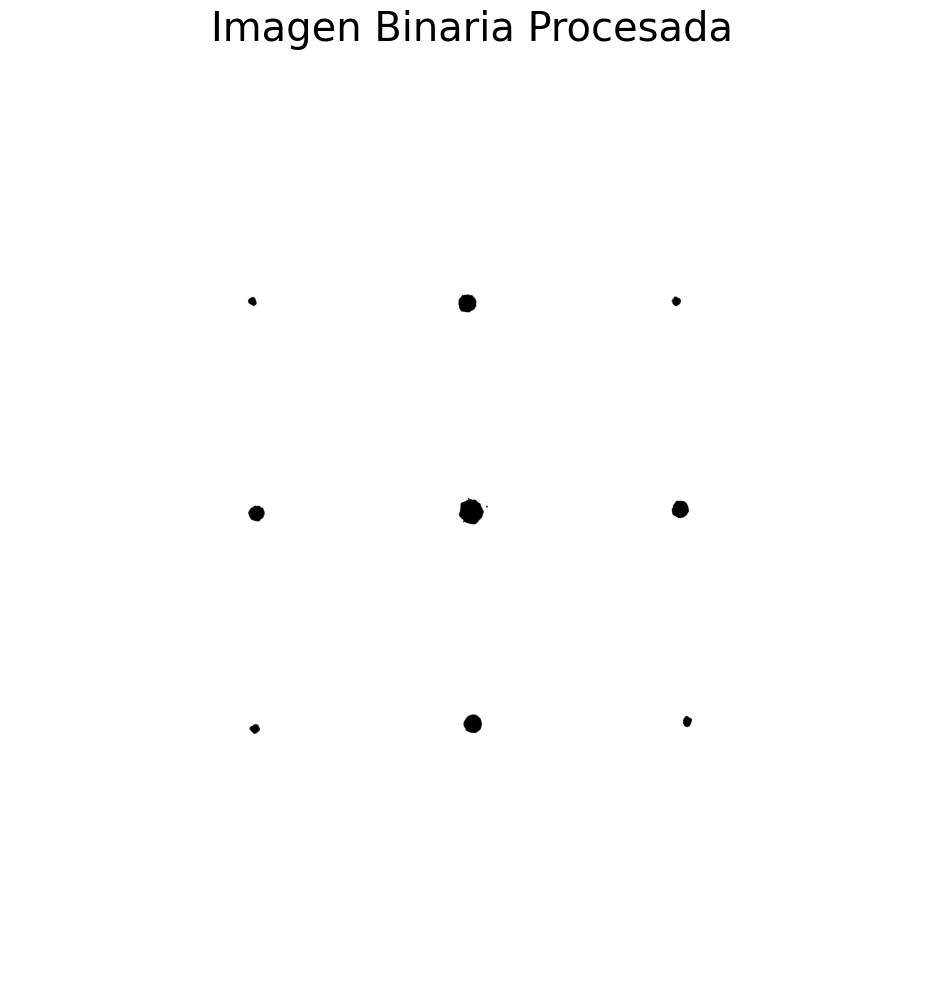

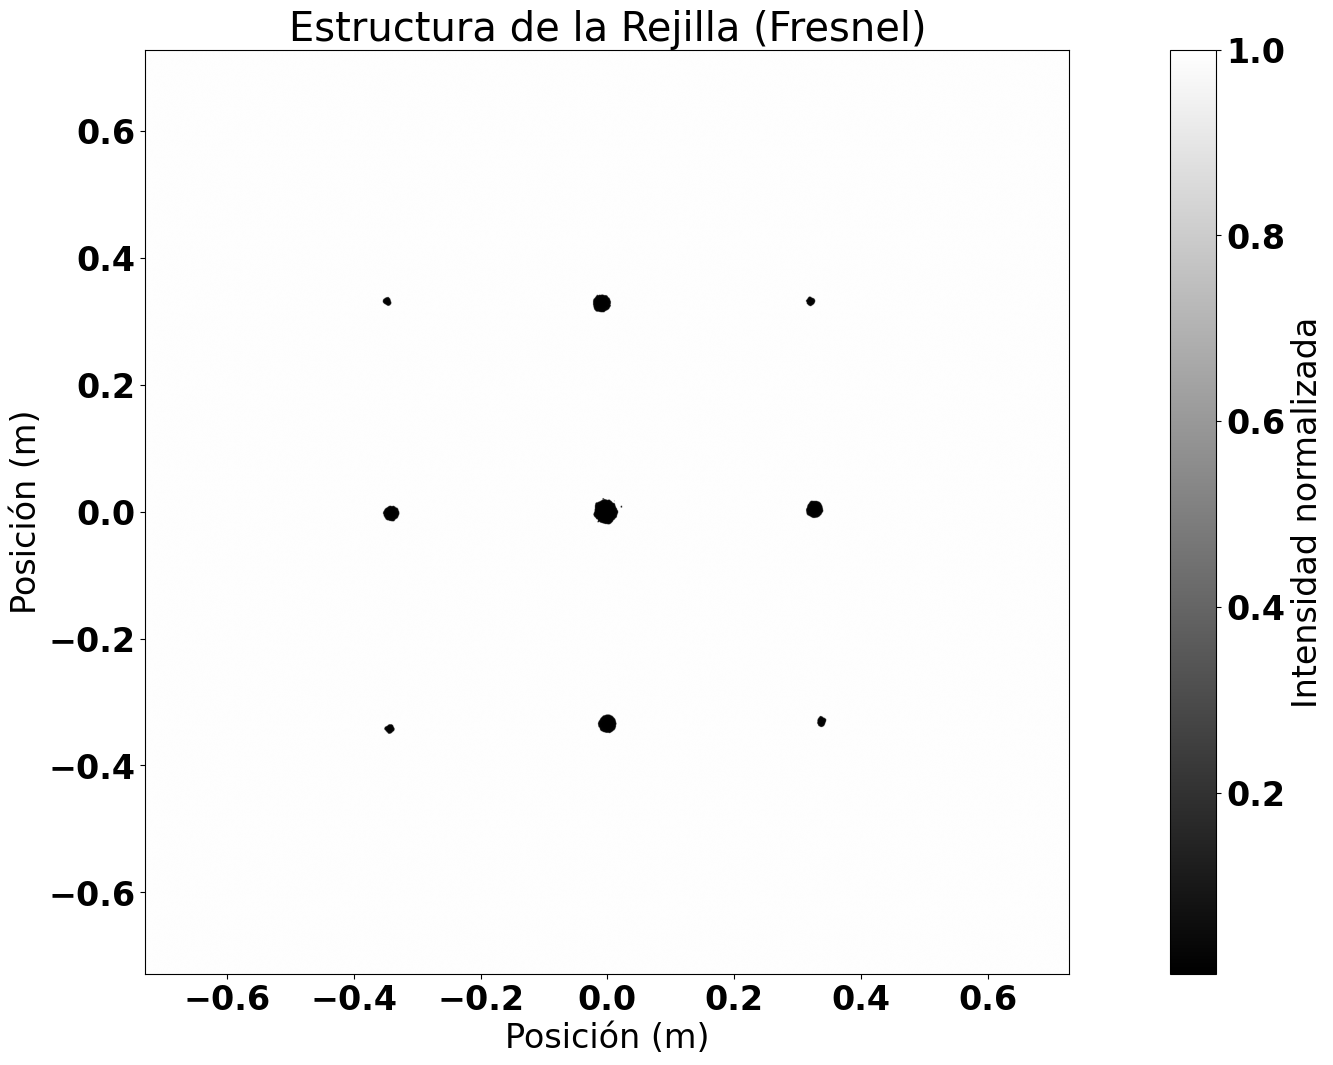

In [38]:
filename = '/content/drive/MyDrive/Física Experimental III/Prelaboratorio 1/Imagenes/Difracción-rejilla-fresnel.jpg'
difraccion_procesada(filename, modo='fresnel', resolucion=0.12 / 249)